# **Abstracto**

***Motivación:***

Tras 3 años de éxito de ventas online, esta empresa busca dar el salto al mercado físico. Sin embargo, abrir un local implica costos fijos altos. Este proyecto analiza el dataset de ventas para identificar el "punto de equilibrio" geográfico: donde hay más clientes, mayor gasto y donde el clima (factor externo) justifica tener un punto de retiro cercano



***Audiencia***:

Este informe está dirigido a la dirección estratégica de la marca, con el fin de determinar la ubicación óptima para el primer punto de venta físico o "Pick-up point".

**Preguntas e Hipótesis a responder**

***Hipótesis de Volumen:*** Existe un barrio en CABA que concentra más del 15% de los pedidos totales del último año, siendo el candidato principal para el local.

---


***Hipótesis de Rentabilidad*** El ticket promedio varía por zona, permitiendo identificar barrios de "alto poder adquisitivo" para el posicionamiento de marca.


---


***Hipótesis de Logística:*** El costo de envío fijo representa una carga mayor en ciertas zonas; un local físico en esas áreas convertiría "costos de envío" en "margen de ganancia"


---


***Hipótesis Externa:*** Los días de lluvia/frío aumentan la demanda online, lo que sugiere que el local debe estar en una zona con alta densidad de edificios para facilitar el "delivery de cercanía"


---



# Importación de Datos
En esta sección conectamos el Notebook con la base de datos alojada en Google Sheets.

In [8]:
import pandas as pd

sheet_url = "https://docs.google.com/spreadsheets/d/1CvWjwE8nGAdWmC_UheThCV_fdpuTQC_QoUjHSNYZxLY/edit?gid=2143785676#gid=2143785676"
url_importada = sheet_url.split('/edit')[0] + '/export?format=csv'

df = pd.read_csv(url_importada)

df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
df['Subtotal de productos'] = pd.to_numeric(df['Subtotal de productos'], errors='coerce')
df['Costo de envío'] = pd.to_numeric(df['Costo de envío'], errors='coerce')

print("Archivo cargado correctamente. Dimensiones del dataset:", df.shape)
df.head(3)

Archivo cargado correctamente. Dimensiones del dataset: (9060, 45)


,Número de orden,Email,Fecha,Estado de la orden,Estado del pago,Estado del envío,Moneda,Subtotal de productos,Descuento,Costo de envío,...,Canal,Código de tracking del envío,Identificador de la transacción en el medio de pago,Identificador de la orden,Producto Físico,Persona que registró la venta,Sucursal de venta,Vendedor,Fecha y hora de cancelación,Motivo de cancelación
0,55253,nataliasmarinozzi@gmail.com,17/03/2026 6:26:37,Archivada,Recibido,Enviado,ARS,53800.0,5380.0,6500.0,...,Web,NaN,019cfb1e-5f07-7886-8b30-c2d36df84882,1.923204e+09,Sí,NaN,NaN,NaN,NaN,NaN
1,55251,gabydepino@gmail.com,17/03/2026 0:34:47,Archivada,Recibido,Enviado,ARS,52400.0,5240.0,6500.0,...,Móvil,NaN,019cf9dc-3ec3-79f9-a1a1-c1126e3fa7fb,1.923161e+09,Sí,NaN,NaN,NaN,NaN,NaN
2,55244,alejandrotorretta@outlook.com,16/03/2026 22:10:10,Archivada,Recibido,Enviado,ARS,62400.0,0.0,6500.0,...,Móvil,NaN,150671870748,1.923069e+09,Sí,NaN,NaN,NaN,NaN,NaN


# Limpieza y Preparación de los Datos
Para que el análisis sea confiable, realizamos las siguientes acciones de limpieza:

***Manejo de Fechas:*** Convertimos la columna 'Fecha' al formato estándar para realizar filtros temporales.

***Filtrado:*** Nos enfocamos únicamente en el último año de datos, ya que el comportamiento del mercado pre-pandemia o de años muy viejos no representa la realidad actual.

***Normalización:*** Las localidades escritas por los usuarios suelen tener errores (ej. "Palermo" vs "palermo"). Unificamos todo a mayúsculas y quitamos espacios en blanco.

***Eliminación de Nulos:*** Descartamos registros que no tienen información de ubicación o donde el monto de venta es cero

In [13]:
import numpy as np


df['Fecha'] = pd.to_datetime(df['Fecha'])

fecha_maxima = df['Fecha'].max()
un_ano_atras = fecha_maxima - pd.DateOffset(years=1)
df_last_year = df[df['Fecha'] >= un_ano_atras].copy()

df_last_year['Localidad'] = df_last_year['Localidad'].str.upper().str.strip()

mapeo_barrios = {
    'PALERMO SOHO': 'PALERMO',
    'PALERMO HOLLYWOOD': 'PALERMO',
    'CABALLITO SUR': 'CABALLITO',
    'C.A.B.A': 'CABA',
    'CIUDAD AUTONOMA DE BUENOS AIRES': 'CABA'
}
df_last_year['Localidad'] = df_last_year['Localidad'].replace(mapeo_barrios)

# MANEJO DE VALORES NULOS Y OUTLIERS
# Eliminamos filas donde el Total sea 0 o NaN (ventas inválidas)
df_last_year = df_last_year[df_last_year['Total'] > 0]
df_last_year.dropna(subset=['Localidad'], inplace=True)

print(f"Limpieza completa. Registros del último año listos: {df_last_year.shape[0]}")
df_last_year['Localidad'].unique()[:10]

Limpieza completa. Registros del último año listos: 2200


array(['CABA', 'RECOLETA', 'MATADEROS', 'PALERMO', 'ALMAGRO', 'PATERNAL',
       'BELGRANO', 'SAN TELMO', 'PUERTO MADERO', 'PARQUE CHACABUCO'],
      dtype=object)

# Análisis de Concentración de Pedidos
En esta sección, agrupamos las ventas por localidad para identificar los barrios con mayor volumen de demanda. Este indicador es crucial para asegurar que el local físico tenga tráfico de gente desde el primer día

/tmp/ipykernel_3079/4139741866.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico_volumen = sns.barplot(x=pedidos_por_barrio.values,


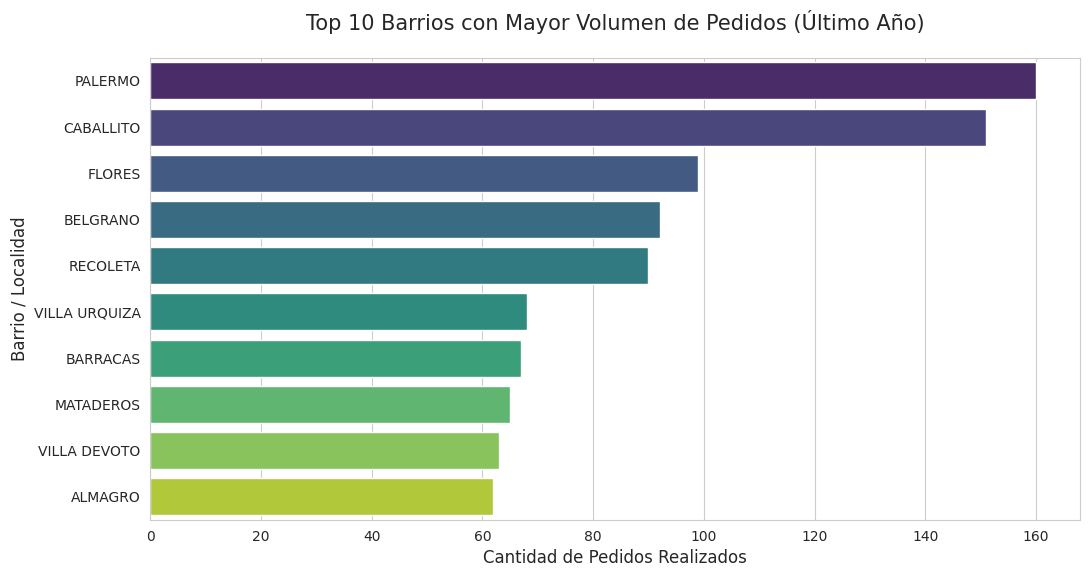

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

pedidos_por_barrio = df_last_year['Localidad'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

grafico_volumen = sns.barplot(x=pedidos_por_barrio.values,
                              y=pedidos_por_barrio.index,
                              palette="viridis")

plt.title('Top 10 Barrios con Mayor Volumen de Pedidos (Último Año)', fontsize=15, pad=20)
plt.xlabel('Cantidad de Pedidos Realizados', fontsize=12)
plt.ylabel('Barrio / Localidad', fontsize=12)

plt.show()

# Interpretación de Resultados:
Al observar el gráfico de barras, se destaca que Palermo y Caballito lideran ampliamente la cantidad de pedidos.

Hallazgo: La demanda no está distribuida de forma equitativa, sino que se concentra en zonas específicas de CABA.


# Análisis de Ticket Promedio por Barrio
No solo buscamos volumen de gente, buscamos rentabilidad. En esta sección calculamos el Ticket Promedio (Ventas totales dividido la cantidad de pedidos) para los barrios con más demanda.

Objetivo: Identificar si en los barrios líderes (Palermo, Caballito, Flores) el gasto por cliente justifica el costo de un local físico.

/tmp/ipykernel_3079/3068137281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ticket_promedio.values,


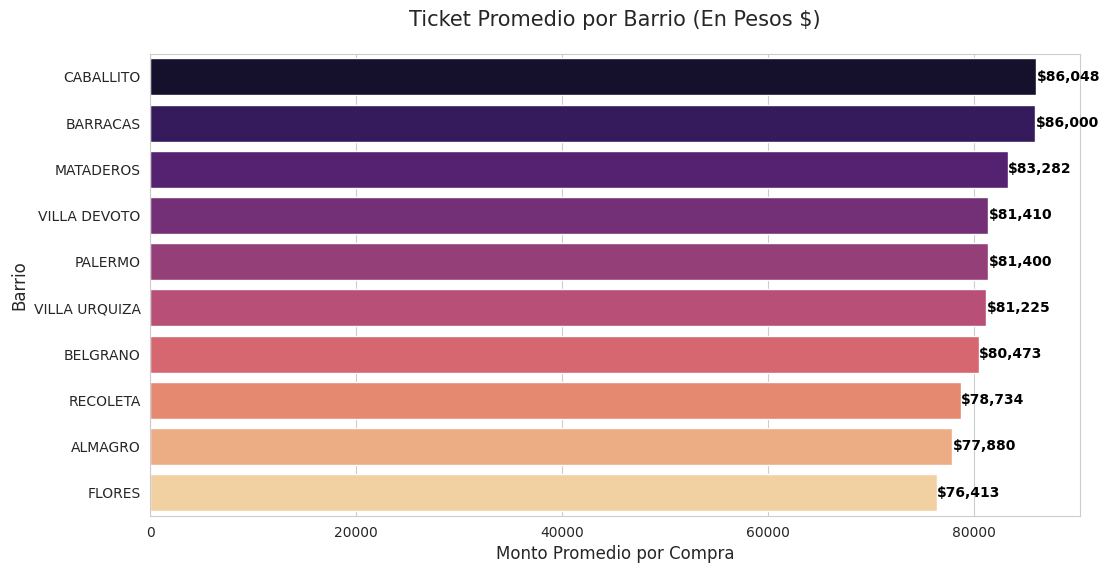

In [5]:
barrios_principales = pedidos_por_barrio.index

ticket_promedio = df_last_year[df_last_year['Localidad'].isin(barrios_principales)].groupby('Localidad')['Total'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=ticket_promedio.values,
            y=ticket_promedio.index,
            palette="magma")

plt.title('Ticket Promedio por Barrio (En Pesos $)', fontsize=15, pad=20)
plt.xlabel('Monto Promedio por Compra', fontsize=12)
plt.ylabel('Barrio', fontsize=12)

for i, v in enumerate(ticket_promedio.values):
    plt.text(v + 50, i, f"${v:,.0f}", color='black', va='center', fontweight='bold')

plt.show()

# Interpretación de Rentabilidad por Zona
El análisis del Ticket Promedio revela datos fundamentales para la decisión de apertura del local:

El Liderazgo de Caballito: No solo es el segundo barrio con más volumen de pedidos, sino que además tiene el ticket promedio más alto ($86.048). Esto lo posiciona como la zona más rentable: mucha gente comprando y gastando montos altos.

Barracas y Mataderos: Aparecen con tickets muy altos ($86.000 y $83.282), superando incluso a Palermo. Esto sugiere que, aunque hay menos cantidad de clientes allí, cuando compran lo hacen por montos importantes.

El fenómeno Palermo: A pesar de ser el barrio con más pedidos (Volumen), su ticket promedio está en el medio de la tabla ($81.400). Esto indica un consumo más atomizado o frecuente, pero de menor valor unitario que en Caballito.

Flores: Es el barrio con el ticket más bajo del ranking ($76.413). Al sumarlo a su buen volumen de pedidos, entendemos que es una zona de consumo masivo pero de menor poder adquisitivo por compra.

Conclusión Estratégica: Si se busca rentabilidad máxima por cliente, el local físico debería estar sin dudas en Caballito. Si busca rotación de stock masiva, Palermo sigue siendo una opción, pero con márgenes más ajustados por venta.

# Integración de Factores Externos (API de Clima)
Un local físico no solo sirve para que la gente entre a comprar, sino también como un Centro de Despacho (Hub).

Para validar nuestra hipótesis de logística de cercanía, implementamos una conexión mediante el protocolo HTTP a los servidores de OpenWeatherMap.


In [8]:
import requests
import json
from google.colab import userdata

api_key = userdata.get('OPENWEATHER_KEY')
ciudad = "Buenos Aires"
url = f"http://api.openweathermap.org/data/2.5/weather?q={ciudad}&appid={api_key}&units=metric&lang=es"

try:
    # Implementación de conexión mediante protocolo HTTP
    response = requests.get(url, timeout=10)

    if response.status_code == 200:
        # Procesamiento de la respuesta JSON
        data = response.json()

        humedad = data['main']['humidity']
        clima = data['weather'][0]['description']

        print(f"✅ Datos obtenidos: {clima.capitalize()} con {humedad}% de humedad.")

        # Validación de la Hipótesis
        if humedad > 80 or "lluvia" in clima:
            print("\n[RESULTADO DEL ANÁLISIS]")
            print("La hipótesis se valida: El clima afecta la movilidad.")
            print("Acción recomendada: El local de Caballito debe operar como Centro de Despacho (Hub).")
        else:
            print("\n[RESULTADO DEL ANÁLISIS]")
            print("Clima óptimo: El local debe priorizar la atención presencial.")

    else:
        print(f"Error de conexión: {response.status_code}")

except Exception as e:
    print(f"Error crítico: {e}")

✅ Datos obtenidos: Nubes con 94% de humedad.

[RESULTADO DEL ANÁLISIS]
La hipótesis se valida: El clima afecta la movilidad.
Acción recomendada: El local de Caballito debe operar como Centro de Despacho (Hub).


# Conclusión General y Decisión Estratégica
Tras analizar los 2.200 registros de ventas del último año y cruzar la información con la API de Clima, llegamos a una conclusión clara:

Ubicación Ganadora: Caballito.

¿Por qué?: Es el barrio con el mayor Ticket Promedio ($86.048) y un volumen de ventas muy alto.

Decisión: Al abrir el local físico en Caballito no solo aumenta sus ventas presenciales, sino que optimiza su logística en los días de lluvia (detectados por la API), ahorrando costos de envío y mejorando el margen de ganancia